In [24]:
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt
import pandas as pd

Zaczynam od rysunków obszarów absolutnej stabilności metod otwartej i zamkniętej Eulera. 

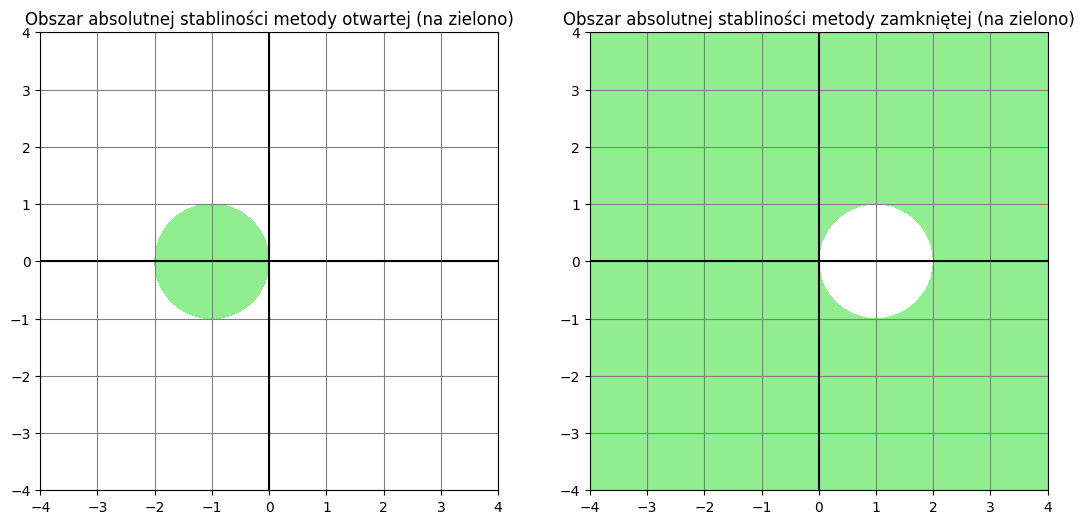

In [25]:
# funkcje stabilności
R_o = lambda z: 1 + z
R_z = lambda z: 1/(1 - z)

# siatka [-4, 4]x[-4, 4] o 1000 punktów podziału każdego wymiaru
x = np.linspace(-4, 4, 1000) 
y = np.linspace(-4, 4, 1000)
X, Y = np.meshgrid(x, y)
Z = X + Y*1j

mask_o = np.abs(R_o(Z))
mask_z = np.abs(R_z(Z))
fig, ax = plt.subplots(1, 2, figsize = (13, 10))
ax[0].contourf(X, Y, mask_o < 1, colors = ['white', 'lightgreen'])
ax[0].set_aspect('equal')
ax[0].axvline(color = 'black')
ax[0].axhline(color = 'black')
ax[0].set_title('Obszar absolutnej stabliności metody otwartej (na zielono)')
ax[0].grid(color = 'grey')
ax[1].contourf(X, Y, mask_z < 1, colors = ['white', 'lightgreen'])
ax[1].set_aspect('equal')
ax[1].axvline(color = 'black')
ax[1].axhline(color = 'black')
ax[1].set_title('Obszar absolutnej stabliności metody zamkniętej (na zielono)')
ax[1].grid(color = 'grey')
plt.show()

Teraz będę porównywał błędy otwartej i zamkniętej metody Eulera. Jako błąd metody definiuję moduł różnicy między wartościami przybliżenia oraz funkcji w prawym końcu przedziału. 

In [26]:
f = lambda λ, t, x: λ*(x - np.cos(t)) - np.sin(t) # Problem Prothero-Robinsona
φ = lambda t: np.cos(t) # rozwiązanie dokładne

# szukanie wzoru na przybliżenie w k+1 - węźle zamkniętej metody Eulera
xk1, xk, tk1, h, λ = sp.symbols('xk1 xk tk1 h λ')
wzor_xk1 = sp.Eq(xk1, xk + h*(λ*(xk1-sp.cos(tk1)) - sp.sin(tk1)))
wzor_na_xk1 = sp.solve(wzor_xk1, xk1)

# funkcja generująca kolejny krok w zamkniętej metodzie Eulera
def xk1_zamknieta(xk, tk1, h, λ):
    return (h*λ*np.cos(tk1) + h*np.sin(tk1) - xk)/(h*λ - 1)

# funkcja generująca kolejny krok w otwartej metodzie Eulera
xk1_otwarta = lambda xk, tk, h, λ: xk + h*f(λ, tk, xk)

ns = [10, 20, 50, 100, 500, 1000, 5000] # lista z kolejnymi liczbami punktów podziałów
hs = [1/(h-1) for h in ns] # lista z kolejnymi długościami kroków
lambdas = [-2*5**i for i in range(7)] # lista kolejnych parametrów λ

for λ in lambdas:
    print(f'\n\nDla λ={λ}:')
    x_otwarte_punkty_koncowe = []
    x_zamkniete_punkty_koncowe = []
    for n in ns:
        x_otw = np.zeros(n)
        x_zamk = np.zeros(n)
        t = np.linspace(0, 1, n)
        x_otw[0] = 1
        x_zamk[0] = 1
        for k in range(n-1):
            x_otw[k+1] = xk1_otwarta(x_otw[k], t[k], 1/(n-1), λ)
            x_zamk[k+1] = xk1_zamknieta(x_zamk[k], t[k+1], 1/(n-1), λ)
        x_otwarte_punkty_koncowe.append(x_otw[-1])
        x_zamkniete_punkty_koncowe.append(x_zamk[-1])

        # rysowanie

        # plt.plot(t, np.cos(t), color = 'g', linewidth = 4, label = 'rozwiązanie dokładne')
        # plt.plot(t, x_zamk, color = 'r', linewidth = 2, label = 'metoda zamknięta')
        # plt.plot(t, x_otw, color = 'b', linewidth = 1, label = 'metoda otwarta')
        # plt.title(f'{n} punktów podziału w metodzie otwartej')
        # plt.legend()
        # plt.show()
        
    err_euler_otwarty = [np.abs(np.cos(1) - x) for x in x_otwarte_punkty_koncowe]
    err_euler_zamkniety = [np.abs(np.cos(1) - x) for x in x_zamkniete_punkty_koncowe]
    tabela1 = np.vstack([ns, hs, err_euler_otwarty, err_euler_zamkniety]).T

    tabela = pd.DataFrame(tabela1)
    tabela.columns = ['n', 'h', 'Błąd metody otwartej', 'Błąd metody zamkniętej']
    print(tabela)




Dla λ=-2:
        n         h  Błąd metody otwartej  Błąd metody zamkniętej
0    10.0  0.111111              0.019092                0.017675
1    20.0  0.052632              0.008854                0.008536
2    50.0  0.020408              0.003394                0.003347
3   100.0  0.010101              0.001674                0.001662
4   500.0  0.002004              0.000331                0.000331
5  1000.0  0.001001              0.000165                0.000165
6  5000.0  0.000200              0.000033                0.000033


Dla λ=-10:
        n         h  Błąd metody otwartej  Błąd metody zamkniętej
0    10.0  0.111111              0.003291                0.003562
1    20.0  0.052632              0.001595                0.001657
2    50.0  0.020408              0.000626                0.000635
3   100.0  0.010101              0.000311                0.000313
4   500.0  0.002004              0.000062                0.000062
5  1000.0  0.001001              0.000031          

/tmp/ipykernel_338853/754895036.py:1: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda λ, t, x: λ*(x - np.cos(t)) - np.sin(t) # Problem Prothero-Robinsona
/tmp/ipykernel_338853/754895036.py:14: RuntimeWarning: invalid value encountered in scalar add
  xk1_otwarta = lambda xk, tk, h, λ: xk + h*f(λ, tk, xk)
/tmp/ipykernel_338853/754895036.py:1: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda λ, t, x: λ*(x - np.cos(t)) - np.sin(t) # Problem Prothero-Robinsona
/tmp/ipykernel_338853/754895036.py:14: RuntimeWarning: invalid value encountered in scalar add
  xk1_otwarta = lambda xk, tk, h, λ: xk + h*f(λ, tk, xk)


Widzimy powtarzającą się zależność: metoda zamknięta jest dokładniejsza. Natomiast co ciekawsze, kiedy parametr λ oraz liczba kroków n są dostatecznie małe jednocześnie, to metoda otwarta kompletnie "szaleje", rozpoznajemy to zjawisko po dużych (czasem nawet przekraczających zakres liczby float64) wartościach w kolumnie "Błąd metody otwartej" w tabelach dla większych wartości λ (odpowiadające wartości w kolumne "Błąd metody zamkniętej" zachowują się bardzo stabilnie). 